<a href="https://colab.research.google.com/github/Ibrah-N/PNID_Symbol_Detection_For_Large_Complex_Diagrams/blob/main/how_to_finetune_rf_detr_on_detection_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train RF-DETR Object Detection on a Custom Dataset

---

[![hf space](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Spaces-blue)](https://huggingface.co/spaces/SkalskiP/RF-DETR)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-finetune-rf-detr-on-detection-dataset.ipynb)
[![roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/rf-detr)
[![code](https://badges.aleen42.com/src/github.svg)](https://github.com/roboflow/rf-detr)

RF-DETR is a real-time transformer architecture for object detection and instance segmentation developed by Roboflow. Built on a DINOv2 vision transformer backbone, RF-DETR delivers state-of-the-art accuracy and latency trade-offs on [Microsoft COCO](https://cocodataset.org/#home) and [RF100-VL](https://github.com/roboflow/rf100-vl).

RF-DETR uses a DINOv2 vision transformer backbone and supports both detection and instance segmentation in a single, consistent API. All core models and code are released under the Apache 2.0 license.

<img alt="rf_detr_1-4_latency_accuracy_object_detection" src="https://storage.googleapis.com/com-roboflow-marketing/rf-detr/rf_detr_1-4_latency_accuracy_object_detection.png" />

## Environment setup

In [ ]:
from google.colab import drive
drive.mount("Ibrah")

Mounted at Ibrah


### Configure API Key

To fine-tune RF-DETR, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy` to copy your private API key.
- In Colab, go to the left pane and click on `Secrets` (🔑).
    - Store your Roboflow API Key under the name `ROBOFLOW_API_KEY`.

In [ ]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("r_b_ibrah")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Thu Jan 22 19:16:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   38C    P8             11W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install dependencies

Installs RF-DETR version 1.4.0 or higher, along with Supervision for benchmarking and Roboflow for pulling datasets and uploading models to the Roboflow platform.

In [ ]:
!pip install -q rfdetr>=1.4.0 supervision roboflow

In [ ]:
!pip install rfdetr>=1.5.2

### Download example data

Downloads example images for testing. You can use these or replace them with your own images.

In [ ]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with Pre-trained COCO Model

Runs inference on an example image using a pretrained RF-DETR Medium model (trained on COCO). To use a different model size, simply replace `RFDETRMedium` with `RFDETRNano`, `RFDETRSmall`, `RFDETRBase` or `RFDETRLarge` as needed.

[2026-03-22 02:09:04] [INFO] rf-detr - Downloading pretrained weights for rf-detr-medium.pth


rf-detr-medium.pth:   0%|          | 0.00/386M [00:00<?, ?iB/s]

[2026-03-22 02:09:31] [INFO] rf-detr - MD5 validation successful for rf-detr-medium.pth


[2026-03-22 02:09:31] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-22 02:09:31] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-22 02:09:32] [INFO] rf-detr - File rf-detr-medium.pth already exists with correct MD5 hash.


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


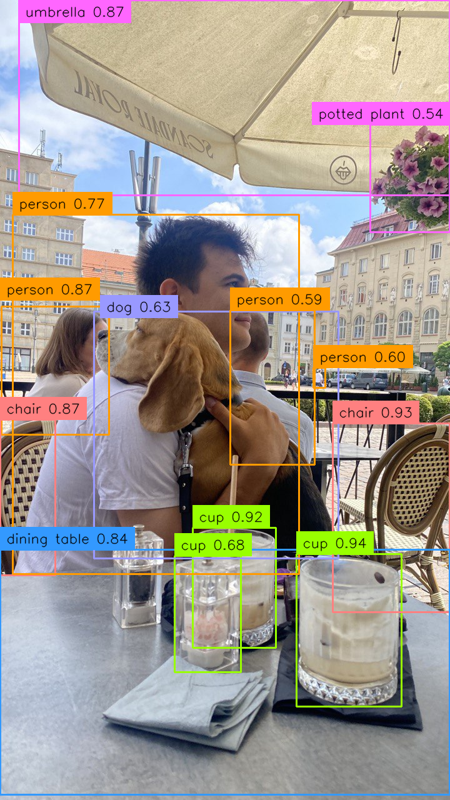

In [ ]:
import numpy as np
import supervision as sv

from PIL import Image

from rfdetr import RFDETRMedium
from rfdetr.util.coco_classes import COCO_CLASSES

image = Image.open("dog-2.jpeg")

model = RFDETRMedium(resolution=640)
model.optimize_for_inference()

detections = model.predict(image, threshold=0.5)

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = bbox_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels)
annotated_image.thumbnail((800, 800))
annotated_image

## Download Dataset from Roboflow Universe

RF-DETR expects the dataset to be in COCO format. Divide your dataset into three subdirectories: `train`, `valid`, and `test`. Each subdirectory should contain its own `_annotations.coco.json` file that holds the annotations for that particular split, along with the corresponding image files. Below is an example of the directory structure:

```
dataset/
├── train/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
├── valid/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
└── test/
    ├── _annotations.coco.json
    ├── image1.jpg
    ├── image2.jpg
    └── ... (other image files)
```

[Roboflow](https://roboflow.com/annotate) allows you to create object detection datasets from scratch or convert existing datasets from formats like YOLO, and then export them in COCO JSON format for training. You can also explore [Roboflow Universe](https://universe.roboflow.com/) to find pre-labeled datasets for a range of use cases.

In [ ]:
from roboflow import download_dataset

dataset = download_dataset("https://universe.roboflow.com/roboflow-jvuqo/basketball-player-detection-2/13", "coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to basketball-player-detection-2-13 in coco:: 100%|██████████| 1406/1406 [00:00<00:00, 4046.39it/s]


## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

In [ ]:
!pip install roboflow

In [ ]:
from google.colab import userdata
from roboflow import Roboflow
rf = Roboflow(api_key=str(userdata.get("r_b_ibrah")))
project = rf.workspace("institute-of-management-sciences-eacvm").project("symbol_detection_v2-dtl7r")
version = project.version(3)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to symbol_detection_v2-3 in coco:: 100%|██████████| 6875/6875 [00:02<00:00, 2782.47it/s]


In [ ]:
!pip install -q pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.4 MB/s eta 0:00:00


In [ ]:
!pip install faster-coco-eval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 17.7 MB/s eta 0:00:00


In [ ]:
import wandb

wandb.login(key=str(userdata.get("wandb")))
run = wandb.init(project="PNID_Models", entity="ibrahnengineer", job_type="download", anonymous="allow")

artifact = run.use_artifact("chines_model:v0", type="model")
artifact_dir = artifact.download()

print("Artifact downloaded at:", artifact_dir)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ibrahnengineer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Downloading large artifact 'chines_model:v0', 129.66MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:04.2 (31.1MB/s)


Artifact downloaded at: /content/artifacts/chines_model:v0


In [ ]:
from rfdetr import RFDETRLarge

model = RFDETRLarge()

model.train(dataset_dir="/content/symbol_detection_v2-3",
            epochs=20, batch_size=2, grad_accum_steps=2,
            resume="/content/artifacts/chines_model:v0/24_march_detector.pth")

Val — Overall Metrics                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.7236 │ 0.9438 │ 0.8029 │ 0.7637 │ 0.9293 │ 0.9398 │ 0.9189 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┘

                  Val — Per-class Metrics                  
┏━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓
┃ Class ┃ AP 50:95 ┃     AR ┃     F1 ┃ Precision ┃ Recall ┃
┡━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩
│ 0     │   0.7236 │ 0.7637 │ 0.9293 │    0.9398 │ 0.9189 │
└───────┴──────────┴────────┴────────┴───────────┴────────┘

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [ ]:
11:30;

In [ ]:
27% potassium chlorate;
18% lactose;
16% mangnesium carbonate;
3% baking soda;
36% organic solvent dye;
red 111, blue 104; available on ebay;

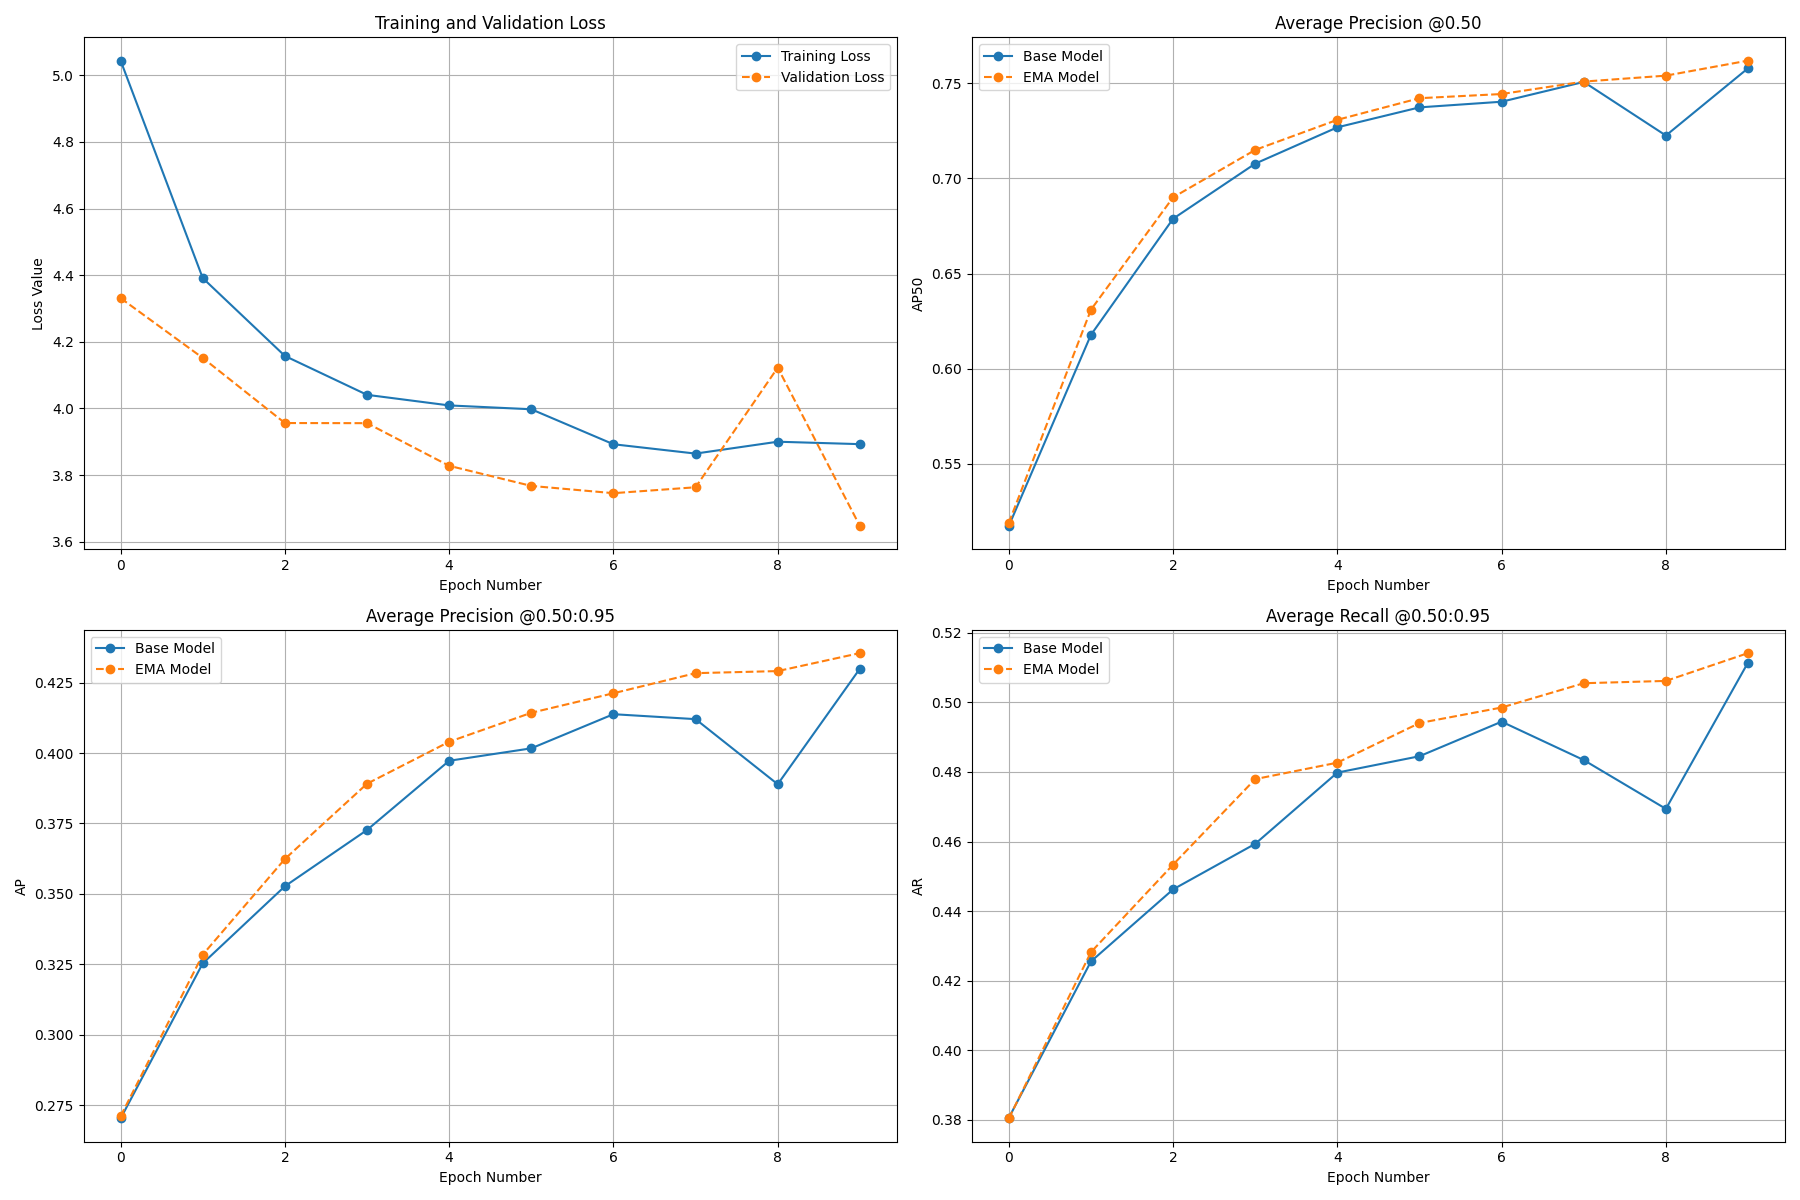

In [ ]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

In [ ]:
!ls -la /content/output

total 1774316
drwxr-xr-x 3 root root      4096 Jan 22 19:33 .
drwxr-xr-x 1 root root      4096 Jan 22 19:21 ..
-rw-r--r-- 1 root root 484664813 Jan 22 19:33 checkpoint0009.pth
-rw-r--r-- 1 root root 362610474 Jan 22 19:33 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 363841030 Jan 22 19:33 checkpoint_best_regular.pth
-rw-r--r-- 1 root root 120840095 Jan 22 19:33 checkpoint_best_total.pth
-rw-r--r-- 1 root root 484655501 Jan 22 19:33 checkpoint.pth
drwxr-xr-x 2 root root      4096 Jan 22 19:22 eval
-rw-r--r-- 1 root root      4412 Jan 22 19:33 events.out.tfevents.1769109679.cc039bb6718a.2442.0
-rw-r--r-- 1 root root     62193 Jan 22 19:33 log.txt
-rw-r--r-- 1 root root    173403 Jan 22 19:33 metrics_plot.png
-rw-r--r-- 1 root root      1874 Jan 22 19:33 results.json


## Deploy a Trained RF-DETR Model

Deploying to Roboflow allows you to create multi-step computer vision applications that run both in the cloud and your own hardware. Please wait a moment while Roboflow indexes your model.

In [ ]:
model.deploy_to_roboflow(
  workspace="roboflow-jvuqo",
  project_id="basketball-player-detection-2",
  version=13,
  api_key=os.environ["ROBOFLOW_API_KEY"]
)

loading Roboflow workspace...
loading Roboflow project...
View the status of your deployment at: https://app.roboflow.com/roboflow-jvuqo/basketball-player-detection-2/13
Share your model with the world at: https://universe.roboflow.com/roboflow-jvuqo/basketball-player-detection-2/model/13


## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [ ]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [ ]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 13890.34 MB | Reserved: 14536.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 334.69 MB | Reserved: 4666.00 MB


We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRMedium` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [2]:
from google.colab import drive
drive.mount('Ibrah')

Mounted at Ibrah


In [2]:
!pip install rfdetr==1.5.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 49.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.5/189.5 kB 82.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 91.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 782.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 42.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless


In [ ]:
!pip install rfdetr==1.5.2
!pip install -q pytorch-lightning
!pip install faster-coco-eval

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
^C


In [1]:
from rfdetr import RFDETRLarge

model = RFDETRLarge(pretrain_weights="/content/artifacts/chines_model:v0/24_march_detector.pth")
model.optimize_for_inference()

[2026-04-02 14:40:06] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-02 14:40:06] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-02 14:40:10] [INFO] rf-detr - Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [ ]:
#==============================#
#          IBRAH CODE          #
#==============================#

from PIL import Image
import random
import cv2
import numpy as np
import os


def draw(image, box, conf):

    # Random color for each box
    color = (random.randint(0,255), random.randint(0, 255), random.randint(0, 255))
    image = cv2.rectangle(image,
                          (int(box[0]), int(box[1])),
                          (int(box[2]), int(box[3])),
                          color, 2
                          )
    image = cv2.putText(image, f"{conf:.2f}",
                        (int(box[0]), int(box[1])),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        color,
                        1)
    return image



if __name__=="__main__":
  # paths
  image_dir = "/content/symbol_detection_v2-3/valid"
  save_dir = "/content/chines_results_v2"
  os.makedirs(save_dir, exist_ok=True)


  for img_idx, img_name in enumerate(os.listdir(image_dir)):

    if not img_name.lower().endswith(".jpg"):
      continue

    # detection
    img_path = os.path.join(image_dir, img_name)
    image = Image.open(img_path)
    detections = model.predict(image, threshold=0.25)

    # xyxy, confs
    objs = detections.xyxy
    confs = detections.confidence
    image = np.array(image)

    # draw
    for Idx in range(len(objs)):
      image = draw(image, objs[Idx], confs[Idx])

    # write
    write_path = os.path.join(save_dir, f"{img_idx}_{img_name}")
    cv2.imwrite(write_path, image)
    print("No {} image {} saved to {}".format(img_idx, img_name, write_path))
    # break

No 0 image resized_30-YB20-D-602-TYPICAL-STRING-DRAWING-FOR-MP-PS3-2-2_patch_2_0_jpg.rf.3b375544dbccbc88dd8d444b7b00f58d.jpg saved to /content/chines_results_v2/0_resized_30-YB20-D-602-TYPICAL-STRING-DRAWING-FOR-MP-PS3-2-2_patch_2_0_jpg.rf.3b375544dbccbc88dd8d444b7b00f58d.jpg
No 1 image 02-Stn_-Outlet_PID_patch_1_3_jpg.rf.0e8f00056711c7fcf6146d020eb9db7f.jpg saved to /content/chines_results_v2/1_02-Stn_-Outlet_PID_patch_1_3_jpg.rf.0e8f00056711c7fcf6146d020eb9db7f.jpg
No 2 image bw_image_3_1_patch_3_2_jpg.rf.7cb8ee729f74019ac8d3f0dd9f708875.jpg saved to /content/chines_results_v2/2_bw_image_3_1_patch_3_2_jpg.rf.7cb8ee729f74019ac8d3f0dd9f708875.jpg
No 3 image bw_image_8_1_patch_2_2_jpg.rf.a5d808fe1d4eace873fb32585aded2af.jpg saved to /content/chines_results_v2/3_bw_image_8_1_patch_2_2_jpg.rf.a5d808fe1d4eace873fb32585aded2af.jpg
No 4 image SE-P-FP-0426_FURNACE-4-FUEL-GAS-TO-COIL-G_patch_1_3_jpg.rf.4be26180d49c68bc06366715eb47a3b0.jpg saved to /content/chines_results_v2/4_SE-P-FP-0426_FURN

In [1]:
import wandb
from google.colab import userdata

wandb.login(key=str(userdata.get("wandb")))
run = wandb.init(project="PNID_Models", entity="ibrahnengineer", job_type="download", anonymous="allow")

artifact = run.use_artifact("chines_model:v0", type="model")
artifact_dir = artifact.download()


print("Artifact downloaded at:", artifact_dir)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ibrahnengineer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


wandb: Downloading large artifact 'chines_model:v0', 129.66MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:03.3 (38.9MB/s)


Artifact downloaded at: /content/artifacts/chines_model:v0


In [7]:
!pip install roboflow

In [2]:
!pip install -q rfdetr==1.5.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.5/189.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.5 MB/s eta 0:00:00


In [3]:
from rfdetr import RFDETRLarge

model = RFDETRLarge(pretrain_weights="/content/artifacts/chines_model:v0/24_march_detector.pth")
model.optimize_for_inference()

[2026-04-02 16:07:02] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-02 16:07:02] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-02 16:07:03] [INFO] rf-detr - Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [9]:
#=====================================#
#          IBRAH WRITTEN SCRIPT       #
#=====================================#

import random
import cv2
import numpy as np
from roboflow import Roboflow
import os



def xyxy_to_yoloC(boxes, img_w, img_h, class_id=0):
  """Converting xyxy to yolo format.

    Args:
      box: list [[x1, y1, x2, y2], ...]

    Return:
      list: [[x_cen, y_cen, width, height]]
  """
  yolo_bboxes = []
  for box in boxes:
    x1, y1, x2, y2 = box

    # xyxy -> xywh
    width = x2 - x1
    height = y2 - y1
    x_center = x1 + width / 2
    y_center = y1 + height / 2

    # normalize
    x_center /= img_w
    y_center /= img_h
    width /= img_w
    height /= img_h

    yolo_bboxes.append("{} {} {} {} {}".format(class_id, x_center, y_center, width, height))

  return yolo_bboxes



def write_txt_file(file_path, data):
  """Write txt file in format of yolo

  Args:
    file_path: the text file to be saved
    data: list: the bounding boxes list
  """

  with open(file_path, 'w') as file_w:
    for line in data:
      file_w.write(line + "\n")



def patch_image(image, patch_size=1792, idx=0):
  """
  Splits image into patches of size patch_size x patch_size.
  Pads the last patches if needed.

  Args:
    image : image arrray
    patch_size: the image to be patch

  Return:
    dict{img_path: image_array, ...} of all patches
  """

  h, w, c = image.shape
  patches = {}

  for y in range(0, h, patch_size):
      for x in range(0, w, patch_size):

          patch = image[y:y+patch_size, x:x+patch_size]

          ph, pw = patch.shape[:2]

          # If patch is smaller → pad it
          if ph < patch_size or pw < patch_size:
              padded = np.zeros((patch_size, patch_size, c), dtype=image.dtype)
              padded[:ph, :pw] = patch
              patch = padded

          patches[f"{idx}_{x}_{y}_img_"] = patch

  return patches


def inference_model(image, threshold=0.25):
  """Run detection for symobls in image

  Args:
    image: patch image path

  Return:
    list of detected boxes
  """

  # detection
  global model
  detections = model.predict(image, threshold=threshold)

  # xyxy, confs
  objs = detections.xyxy
  confs = detections.confidence

  return objs



def upload_to_roboflow(dataset_dir, keys, workspace, project, num_worker=5):

  rf = Roboflow(api_key=str(keys))

  workspace = rf.workspace(workspace)

  workspace.upload_dataset(
      dataset_path=dataset_dir,
      project_name=project,
      num_workers=num_worker
  )


def main(test_mode=False, read_root=None, save_root=None,
         patch_size=1792, upload_roboflow=False,
         roboflow_keys=None, roboflow_workspace=None,
         roboflow_project=None, roboflow_num_worker=None):

  # save dataset structure
  save_images_path = os.path.join(save_root, "images")
  save_labels_path = os.path.join(save_root, "labels")

  os.makedirs(save_images_path, exist_ok=True)
  os.makedirs(save_labels_path, exist_ok=True)

  # read images
  read_images_list = os.listdir(read_root)

  for Idx, img_p in enumerate(read_images_list):
    image_path = os.path.join(read_root, img_p)

    if not (image_path.lower().endswith(".jpg") or
            image_path.lower().endswith(".png")):
      continue

    # read image
    image = cv2.imread(image_path)

    # patch image
    image_patches = patch_image(image, patch_size, idx=Idx)

    # iterate patches
    if image_patches is None:
      continue

    for patch_idx, patch in enumerate(image_patches.items()):
      image_name = patch[0]
      patch_image_ = patch[1]

      # run inference
      bboxes = inference_model(patch_image_)

      # bboxes into yolo
      bboxes = xyxy_to_yoloC(bboxes, patch_size, patch_size, class_id=0)

      # paths to save image and labels file
      image_save_path = os.path.join(save_images_path, f"{image_name}.jpg")
      label_save_path = os.path.join(save_labels_path, f"{image_name}.txt")

      write_txt_file(label_save_path, bboxes)
      cv2.imwrite(image_save_path, patch_image_)

      print("Image No: {} Patch No: {} Image Saved at: {} Label Saved at: {}"
            .format(Idx, patch_idx, image_save_path, label_save_path))

    if test_mode:
      break

  if upload_roboflow:
    upload_to_roboflow(save_root, roboflow_keys,
                       roboflow_workspace, roboflow_project,
                       roboflow_num_worker)

  if test_mode:
    print("Testing Done! Successfully; Please set test_mode to false, syntex: test_model=False")


if __name__=="__main__":

  # paths
  image_dir = "/content/sample_images" # the patches directory
  save_dir = "/content/generated_dataset"

  main(test_mode=True, read_root=image_dir, save_root=save_dir,
          patch_size=1792, upload_roboflow=True,
          roboflow_keys="r14nN5xHLRh1UKhgQi98", roboflow_workspace="pnid-relgx",
          roboflow_project="testing_script", roboflow_num_worker=5)

Image No: 0 Patch No: 0 Image Saved at: /content/generated_dataset/images/0_0_0_img_.jpg Label Saved at: /content/generated_dataset/labels/0_0_0_img_.txt
Image No: 0 Patch No: 1 Image Saved at: /content/generated_dataset/images/0_1792_0_img_.jpg Label Saved at: /content/generated_dataset/labels/0_1792_0_img_.txt
Image No: 0 Patch No: 2 Image Saved at: /content/generated_dataset/images/0_3584_0_img_.jpg Label Saved at: /content/generated_dataset/labels/0_3584_0_img_.txt
Image No: 0 Patch No: 3 Image Saved at: /content/generated_dataset/images/0_5376_0_img_.jpg Label Saved at: /content/generated_dataset/labels/0_5376_0_img_.txt
Image No: 0 Patch No: 4 Image Saved at: /content/generated_dataset/images/0_7168_0_img_.jpg Label Saved at: /content/generated_dataset/labels/0_7168_0_img_.txt
Image No: 0 Patch No: 5 Image Saved at: /content/generated_dataset/images/0_8960_0_img_.jpg Label Saved at: /content/generated_dataset/labels/0_8960_0_img_.txt
Image No: 0 Patch No: 6 Image Saved at: /conte

In [3]:
#=====================================#
#          IBRAH WRITTEN SCRIPT       #
#=====================================#

from PIL import Image
import random
import cv2
import numpy as np
import os


def draw(image, box, conf):
  """Draw the bbox detections over image.

    Args:
      image: array: numpy image
      box. : list:  [x1, y1, x2, y2]
      conf : float: x.xx

    Return:
      image
  """
  # Random color for each box
  color = (random.randint(0,255), random.randint(0, 255), random.randint(0, 255))
  image = cv2.rectangle(image,
                        (int(box[0]), int(box[1])),
                        (int(box[2]), int(box[3])),
                        color, 2
                        )
  image = cv2.putText(image, f"{conf:.2f}",
                      (int(box[0]), int(box[1])),
                      cv2.FONT_HERSHEY_SIMPLEX,
                      0.5,
                      color,
                      1)
  return image



if __name__=="__main__":
  # paths
  image_dir = "/content/patches" # the patches directory
  save_dir = "/content/chines_results_v2"
  os.makedirs(save_dir, exist_ok=True)


  for img_idx, img_name in enumerate(os.listdir(image_dir)):

    if not img_name.lower().endswith(".jpg"):
      continue

    # detection
    img_path = os.path.join(image_dir, img_name)
    image = Image.open(img_path)
    detections = model.predict(image, threshold=0.25)

    # xyxy, confs
    objs = detections.xyxy
    confs = detections.confidence
    image = np.array(image)

    # draw
    for Idx in range(len(objs)):
      image = draw(image, objs[Idx], confs[Idx])

    # write
    write_path = os.path.join(save_dir, f"{img_idx}_{img_name}")
    cv2.imwrite(write_path, image)
    print("No {} image {} saved to {}".format(img_idx, img_name, write_path))

No 0 image 0_1792_5376_img_.jpg saved to /content/chines_results_v2/0_0_1792_5376_img_.jpg
No 1 image 0_0_3584_img_.jpg saved to /content/chines_results_v2/1_0_0_3584_img_.jpg
No 2 image 0_3584_5376_img_.jpg saved to /content/chines_results_v2/2_0_3584_5376_img_.jpg
No 3 image 1_3584_1792_img_.jpg saved to /content/chines_results_v2/3_1_3584_1792_img_.jpg
No 4 image 0_0_1792_img_.jpg saved to /content/chines_results_v2/4_0_0_1792_img_.jpg


KeyboardInterrupt: 

In [2]:
#===================================================#
#     SCRIPT WRITTEN BY GPT UPDATED BY IBRAH        #
#===================================================#

from PIL import Image
import numpy as np
import os
import cv2

def patch_image(image, patch_size=1792, save_dir="/content/patches", idx=0):
    """
    Splits image into patches of size patch_size x patch_size.
    Pads the last patches if needed.
    """

    os.makedirs(save_dir, exist_ok=True)

    if isinstance(image, Image.Image):
        image = np.array(image)

    h, w, c = image.shape
    patches = []

    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):

            patch = image[y:y+patch_size, x:x+patch_size]

            ph, pw = patch.shape[:2]

            # If patch is smaller → pad it
            if ph < patch_size or pw < patch_size:
                padded = np.zeros((patch_size, patch_size, c), dtype=image.dtype)
                padded[:ph, :pw] = patch
                patch = padded

            cv2.imwrite(os.path.join(save_dir, f"{idx}_{x}_{y}_img_.jpg"), patch)
            print("Patch {} Saved to {}".format(f"{idx}_{x}_{y}_img_.jpg", os.path.join(save_dir, f"{x}_{y}_img_.jpg")))


if __name__=="__main__":

  # for single image

  image_p = "/content/201.jpg"
  image = Image.open(image_p)
  patch_image(image, patch_size=1792, save_dir="/content/patches", idx=0)


  # for directory
  # if have multiple drawings. (unpatched diagrams/images)
  '''
  root_path = "/content/sample_img"
  for idx, img_ in enumerate(os.listdir(root_path)):
    image_p = os.path.join(root_path, img_)
    image = Image.open(image_p)
    patch_image(image, patch_size=1792, save_dir="/content/patches", idx=idx)
  '''

Patch 0_0_0_img_.jpg Saved to /content/patches/0_0_img_.jpg
Patch 0_1792_0_img_.jpg Saved to /content/patches/1792_0_img_.jpg
Patch 0_3584_0_img_.jpg Saved to /content/patches/3584_0_img_.jpg
Patch 0_5376_0_img_.jpg Saved to /content/patches/5376_0_img_.jpg
Patch 0_7168_0_img_.jpg Saved to /content/patches/7168_0_img_.jpg
Patch 0_8960_0_img_.jpg Saved to /content/patches/8960_0_img_.jpg
Patch 0_0_1792_img_.jpg Saved to /content/patches/0_1792_img_.jpg
Patch 0_1792_1792_img_.jpg Saved to /content/patches/1792_1792_img_.jpg
Patch 0_3584_1792_img_.jpg Saved to /content/patches/3584_1792_img_.jpg
Patch 0_5376_1792_img_.jpg Saved to /content/patches/5376_1792_img_.jpg
Patch 0_7168_1792_img_.jpg Saved to /content/patches/7168_1792_img_.jpg
Patch 0_8960_1792_img_.jpg Saved to /content/patches/8960_1792_img_.jpg
Patch 0_0_3584_img_.jpg Saved to /content/patches/0_3584_img_.jpg
Patch 0_1792_3584_img_.jpg Saved to /content/patches/1792_3584_img_.jpg
Patch 0_3584_3584_img_.jpg Saved to /content/p

In [ ]:
import cv2
import os
from google.colab.patches import cv2_imshow
import numpy as np
import random




def draw(image, box, conf):
    # Random color for each box
    color = (random.randint(0,255), random.randint(0,255), random.randint(0,255))

    # Draw rectangle
    cv2.rectangle(image,
                  (int(box[0]), int(box[1])),
                  (int(box[2]), int(box[3])),
                  color,
                  2)

    # Put text
    # cv2.putText(image, f"{conf:.2f}", (int(box[0]), int(box[1])-5),
    #             cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return image


output_dir = "/content/results"
os.makedirs(output_dir, exist_ok=True)


for Idx, image_name in enumerate(os.listdir("/content/symbol_detection_v2-2/test")):

  if not image_name.lower().endswith(".jpg"):
    continue
  img_path = os.path.join("/content/symbol_detection_v2-2/test/", image_name)

  image = Image.open(img_path)
  detections = model.predict(image, threshold=0.5)
  objs = detections.xyxy
  confs = detections.confidence

  # Convert once to numpy array
  image_np = np.array(image)

  # Iterate over detections
  for i in range(len(objs)):
      image_np = draw(image_np, objs[i], confs[i])

  write_path = os.path.join(output_dir, image_name)
  cv2.imwrite(write_path, image_np)

In [ ]:
!cp -r /content/output/checkpoint_best_ema.pth -d /content/Ibrah/MyDrive/Symbol_

In [ ]:
!zip -r /content/chines_base_results.zip /content/chines_results_v2

  adding: content/chines_results_v2/ (stored 0%)
  adding: content/chines_results_v2/64_0_7168_0_img_.jpg (deflated 45%)
  adding: content/chines_results_v2/27_2_8960_0_img_.jpg (deflated 46%)
  adding: content/chines_results_v2/41_2_7168_1792_img_.jpg (deflated 24%)
  adding: content/chines_results_v2/66_1_5376_3584_img_.jpg (deflated 42%)
  adding: content/chines_results_v2/7_0_3584_3584_img_.jpg (deflated 22%)
  adding: content/chines_results_v2/57_0_3584_1792_img_.jpg (deflated 19%)
  adding: content/chines_results_v2/69_0_0_5376_img_.jpg (deflated 64%)
  adding: content/chines_results_v2/16_0_0_0_img_.jpg (deflated 34%)
  adding: content/chines_results_v2/24_1_5376_1792_img_.jpg (deflated 26%)
  adding: content/chines_results_v2/45_2_8960_1792_img_.jpg (deflated 54%)
  adding: content/chines_results_v2/10_2_0_1792_img_.jpg (deflated 40%)
  adding: content/chines_results_v2/54_1_3584_1792_img_.jpg (deflated 20%)
  adding: content/chines_results_v2/60_2_1792_1792_img_.jpg (deflated 

In [ ]:
!cp -r

In [ ]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 169/169 [00:05<00:00, 30.23it/s]


In [ ]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.446
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.770
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.436
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.213
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.691
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.842


## push model to wandb

In [ ]:
import wandb

In [ ]:
from google.colab import userdata

wandb.login(key=str(userdata.get("wandb")))

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [ ]:

run = wandb.init(
    project = "PNID_Models",
    name = "Symbol_Detector_V2"
)

In [ ]:
artifact = wandb.Artifact(
    name = "chines_model_v1",
    type = "model",
    description = "Base Trained model"
)

In [ ]:
!cp -r /content/Ibrah/MyDrive/Symbol_/checkpoint_best_ema.pth -d /content/

In [ ]:
artifact.add_file("/content/output/last.ckpt")
artifact.add_file("/content/output/checkpoint_best_regular.pth")

ArtifactManifestEntry(path='checkpoint_best_regular.pth', digest='A/7y+jpEIwVS5lV4bUqUMg==', size=135956085, local_path='/root/.local/share/wandb/artifacts/staging/tmpif6pef4r', skip_cache=False)

In [ ]:
run.log_artifact(artifact)

<Artifact chines_model_v1>

In [ ]:
run.finish()

In [1]:
import wandb
from google.colab import userdata

wandb.login(key=str(userdata.get("wandb")))
run = wandb.init(project="PNID_Models", entity="ibrahnengineer", job_type="download", anonymous="allow")

artifact = run.use_artifact("chines_model:v0", type="model")
artifact_dir = artifact.download()

print("Artifact downloaded at:", artifact_dir)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ibrahnengineer to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


wandb: Downloading large artifact 'chines_model:v0', 129.66MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:10.0 (13.0MB/s)


Artifact downloaded at: /content/artifacts/chines_model:v0


## Run Inference with Fine-tuned RF-DETR Model

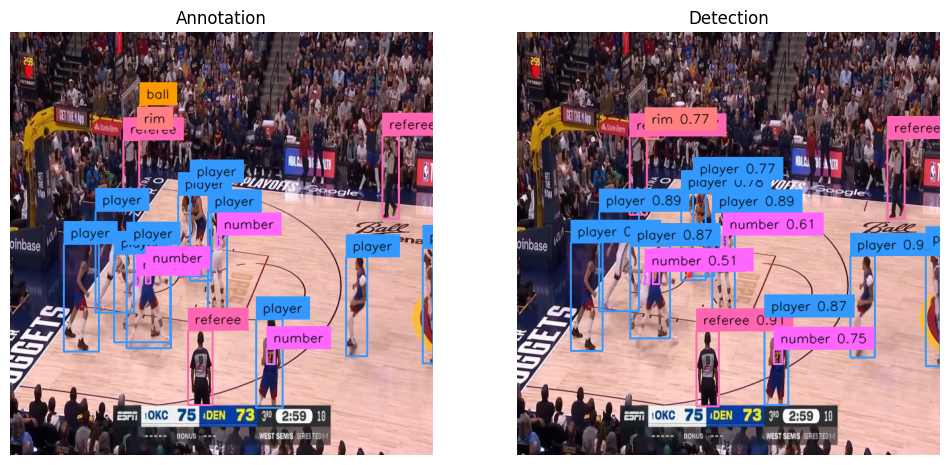

In [ ]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

In [ ]:
from google.colab import drive
drive.mount("Ibrah")

Mounted at Ibrah


In [ ]:
!cp -r /content/output/checkpoint_best_regular.pth -d /content/Ibrah/MyDrive/Symbol_Detection_Chines

In [ ]:
!pip install -q inference

In [ ]:
from inference import get_model

MODEL_ID = "basketball-player-detection-2/13"
model_rf = get_model(model_id=MODEL_ID, api_key = userdata.get("ROBOFLOW_API_KEY"))

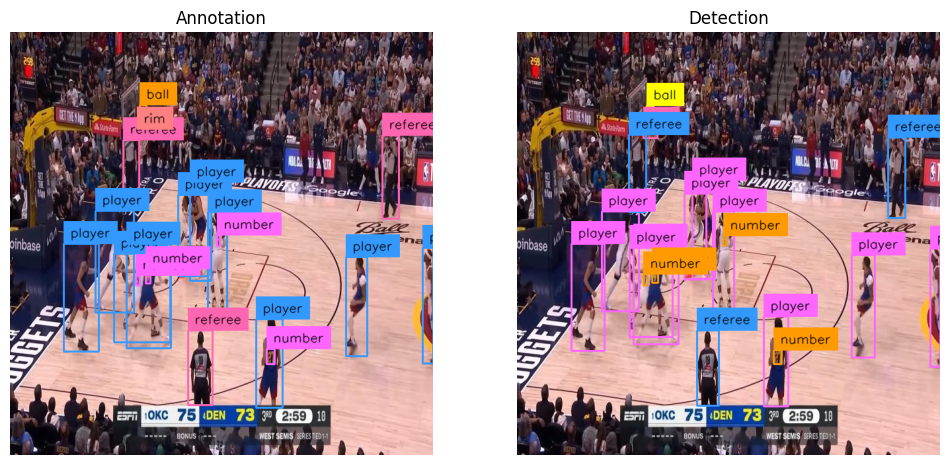

In [ ]:
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

result = model_rf.infer(image, confidence=0.3)[0]
detections = sv.Detections.from_inference(result)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

In [13]:
!rm -rf /content/generated_dataset

In [11]:
###################################################
# script for verifying the dataset
# format of input data
#   - images (.jpg, .png ....)
#   - labels (yolo_format_annotations(cls, x_cen, y_cen, width, height)) # normalized values
#####################################################
import os
import cv2
import random
from google.colab.patches import cv2_imshow


def xywh_to_xyxy(x_center, y_center,
                 bbox_width, bbox_height,
                 img_width, img_height):
  """Converting normalized yolo labels (class_id, x, y, w, h) into unnormalized (class_id, x1, y1, x2, y2)

    Return:
      list (class_id, x1, y1, x2, y2)
  """

  # Denormalize YOLO coords
  x_center *= img_width
  y_center *= img_height
  bbox_width *= img_width
  bbox_height *= img_height

  x1 = int(x_center - bbox_width / 2)
  y1 = int(y_center - bbox_height / 2)
  x2 = int(x_center + bbox_width / 2)
  y2 = int(y_center + bbox_height / 2)

  return [x1, y1, x2, y2]


def draw_bbox(image, lines, line_width=2):
  """Draw bounding box over the image

    Return:
      Image array
  """
  h, w = image.shape[:2]

  for idx_line, line in enumerate(lines):

    parts = line.strip().split()
    if len(parts) != 5:
        continue

    class_id, x_center, y_center, bbox_width, bbox_height = map(float, parts)
    class_id, x1, y1, x2, y2 = int(class_id), *xywh_to_xyxy(x_center, y_center,
                                                            bbox_width, bbox_height,
                                                            w, h)

    # Pick color for this class
    color = (random.randint(0, 255),
            random.randint(0, 255),
            random.randint(0, 255))
    global colors # defined in __name__=="__main__" memory block

    if class_id not in colors.keys():

      while True:
        # prevent duplicate colors for multiple classes
        if color in colors.values():
            color = (random.randint(0, 255),
                    random.randint(0, 255),
                    random.randint(0, 255))
            continue

        else:
          # add new color for new class
          colors[class_id] = color
          break


    color = colors[class_id]

    # Draw rectangle + class ID
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
    cv2.putText(image, str(class_id), (x1, max(20, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

  return image


def verification_main(image_path, label_path, image_save_path):
  """Main Code looping images patha and labels path; saving resltand images

  """

  # read image
  image = cv2.imread(image_path)

  if image is None:
    print(f"Could not read image: {image_path}")
    return

  # read labels
  with open(label_path, 'r') as label_file:
    lines = label_file.readlines()

  image = draw_bbox(image, lines)

  # save image
  cv2.imwrite(image_save_path, image)
  print("Image {} Saved to {}".format(image_path, image_save_path))


In [12]:
###################################################
# REFERENCE: Functions defined in Dataset Utils
#
# script for verifying the dataset
# format of input data
#   - images (.jpg, .png ....)
#   - labels (yolo_format_annotations(cls, x_cen, y_cen, width, height)) # normalized values
#####################################################
import random

if __name__ == "__main__":
  colors = {}

  images_path = "/content/generated_dataset/images"
  labels_path = "/content/generated_dataset/labels"

  save_path = "/content/tests_saved"
  samples = 80 # number of samples to be used
  patch_size = 1792  # Not directly used unless you want to draw grid or check sizes

  os.makedirs(save_path, exist_ok=True)


  for img_idx, img_file in enumerate(random.choices(os.listdir(images_path), k=samples)):

    if not img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        continue

    image_path = os.path.join(images_path, img_file)
    label_path = os.path.join(labels_path, img_file.rsplit('.', 1)[0] + ".txt")

    image_save_path = os.path.join(save_path, img_file)

    verification_main(image_path, label_path, image_save_path)


    if img_idx >= samples:
      break

Image /content/generated_dataset/images/1_8960_0_img_.jpg Saved to /content/tests_saved/1_8960_0_img_.jpg
Image /content/generated_dataset/images/0_5376_1792_img_.jpg Saved to /content/tests_saved/0_5376_1792_img_.jpg
Image /content/generated_dataset/images/0_0_5376_img_.jpg Saved to /content/tests_saved/0_0_5376_img_.jpg
Image /content/generated_dataset/images/2_3584_0_img_.jpg Saved to /content/tests_saved/2_3584_0_img_.jpg
Image /content/generated_dataset/images/0_1792_0_img_.jpg Saved to /content/tests_saved/0_1792_0_img_.jpg
Image /content/generated_dataset/images/2_8960_5376_img_.jpg Saved to /content/tests_saved/2_8960_5376_img_.jpg
Image /content/generated_dataset/images/2_7168_1792_img_.jpg Saved to /content/tests_saved/2_7168_1792_img_.jpg
Image /content/generated_dataset/images/1_1792_5376_img_.jpg Saved to /content/tests_saved/1_1792_5376_img_.jpg
Image /content/generated_dataset/images/2_8960_0_img_.jpg Saved to /content/tests_saved/2_8960_0_img_.jpg
Image /content/generat

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>